# DATA620 Week Six - Assignment Data Sets (v005)

**Author:** Sabina Baraili  
**Course:** DATA620 Web Analytics  

This notebook uses the canonical `davis.dat` file saved in `data/` and analyzes the Davis Southern Women bipartite network.



## 1) Imports and reproducibility setup


In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 50)



## 2) Load canonical dataset from relative path
Source URL used to obtain canonical data:  
`https://raw.githubusercontent.com/networkx/networkx/main/networkx/generators/social.py`



In [2]:
data_path = 'data/davis.dat'
raw_df = pd.read_csv(data_path, sep='	', comment='#')
raw_df.head()



,woman,event
0,Evelyn Jefferson,E1
1,Evelyn Jefferson,E2
2,Evelyn Jefferson,E3
3,Evelyn Jefferson,E4
4,Evelyn Jefferson,E5


In [3]:
women = sorted(raw_df['woman'].unique())
events = sorted(raw_df['event'].unique())

print(f"Dataset confirmation: women={len(women)}, events={len(events)}")
print(f"Attendance edges: {len(raw_df)}")

assert len(women) == 18
assert len(events) == 14



Dataset confirmation: women=18, events=14
Attendance edges: 89


## 3) Build bipartite graph


In [4]:
B = nx.Graph()
B.add_nodes_from(women, bipartite=0, node_type='woman')
B.add_nodes_from(events, bipartite=1, node_type='event')
B.add_edges_from(raw_df[['woman', 'event']].itertuples(index=False, name=None))

print('Is bipartite:', bipartite.is_bipartite(B))
print('Total nodes:', B.number_of_nodes())
print('Total edges:', B.number_of_edges())



Is bipartite: True
Total nodes: 32
Total edges: 89


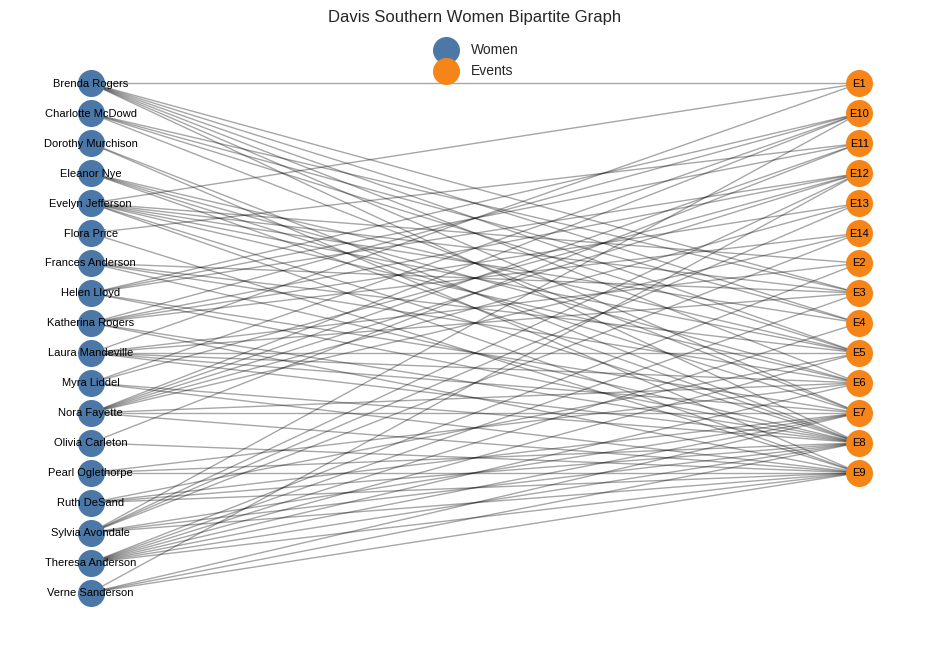

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
pos = {}
for i, w in enumerate(women):
    pos[w] = (0, -i)
for i, e in enumerate(events):
    pos[e] = (1, -i)

nx.draw_networkx_nodes(B, pos, nodelist=women, node_color='#4C78A8', node_size=340, label='Women', ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=events, node_color='#F58518', node_size=340, label='Events', ax=ax)
nx.draw_networkx_edges(B, pos, alpha=0.35, width=1.0, ax=ax)
nx.draw_networkx_labels(B, pos, font_size=8, ax=ax)

ax.set_title('Davis Southern Women Bipartite Graph')
ax.axis('off')
ax.legend(loc='upper center')
plt.show()



## 4) Women projection
Two women are connected when they attended at least one common event. Edge weight = count of shared events.



In [6]:
W = bipartite.weighted_projected_graph(B, women)

women_metrics = pd.DataFrame({
    'weighted_degree': dict(W.degree(weight='weight')),
    'degree_centrality': nx.degree_centrality(W),
    'betweenness_centrality': nx.betweenness_centrality(W, weight='weight'),
    'clustering': nx.clustering(W, weight='weight')
}).sort_values('weighted_degree', ascending=False)

women_metrics.head(10)



,weighted_degree,degree_centrality,betweenness_centrality,clustering
Theresa Anderson,57,1.000000,0.000668,0.351678
Evelyn Jefferson,50,1.000000,0.000668,0.318594
Sylvia Avondale,46,1.000000,0.018464,0.305664
Brenda Rogers,46,0.882353,0.003326,0.359048
Laura Mandeville,45,0.882353,0.003326,0.355817
Nora Fayette,43,1.000000,0.010924,0.293036
Ruth DeSand,40,1.000000,0.000668,0.291210
Verne Sanderson,38,1.000000,0.018464,0.279991
Katherina Rogers,37,0.941176,0.053729,0.283471
Eleanor Nye,36,0.882353,0.004552,0.319688


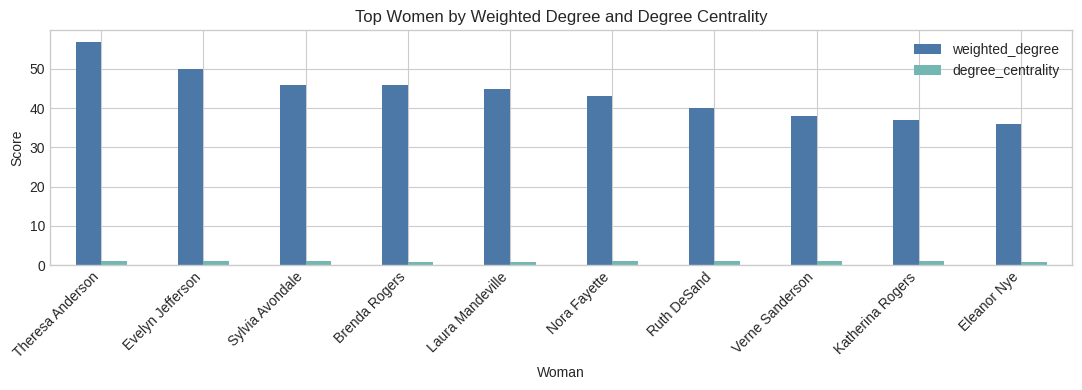

In [7]:
women_metrics[['weighted_degree', 'degree_centrality']].head(10).plot(
    kind='bar', figsize=(11,4), color=['#4C78A8', '#72B7B2']
)
plt.title('Top Women by Weighted Degree and Degree Centrality')
plt.ylabel('Score')
plt.xlabel('Woman')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



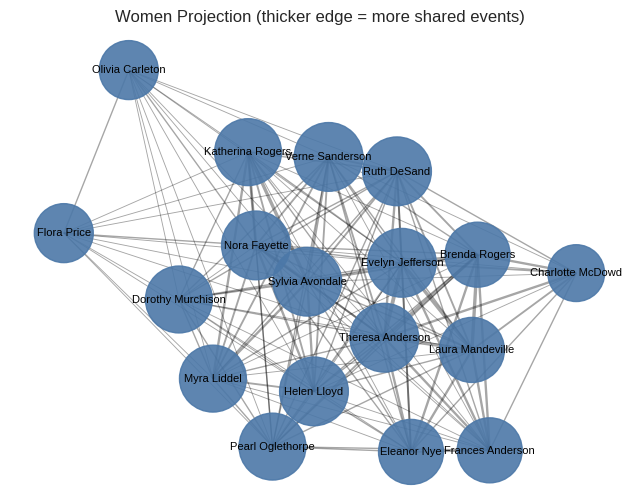

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
pos_w = nx.spring_layout(W, seed=42, weight='weight')
node_sizes = [250 + 2200 * women_metrics.loc[n, 'degree_centrality'] for n in W.nodes()]
edge_widths = [0.3 + 0.35 * d['weight'] for _, _, d in W.edges(data=True)]

nx.draw_networkx_nodes(W, pos_w, node_size=node_sizes, node_color='#4C78A8', alpha=0.9, ax=ax)
nx.draw_networkx_edges(W, pos_w, width=edge_widths, alpha=0.35, ax=ax)
nx.draw_networkx_labels(W, pos_w, font_size=8, ax=ax)

ax.set_title('Women Projection (thicker edge = more shared events)')
ax.axis('off')
plt.show()



## 5) Event projection
Two events are connected when they share at least one attendee. Edge weight = number of shared women.



In [9]:
E = bipartite.weighted_projected_graph(B, events)

event_metrics = pd.DataFrame({
    'weighted_degree': dict(E.degree(weight='weight')),
    'degree_centrality': nx.degree_centrality(E),
    'betweenness_centrality': nx.betweenness_centrality(E, weight='weight'),
    'clustering': nx.clustering(E, weight='weight')
}).sort_values('weighted_degree', ascending=False)

event_metrics.head(10)



,weighted_degree,degree_centrality,betweenness_centrality,clustering
E8,59,1.000000,0.013889,0.292456
E7,48,1.000000,0.028846,0.261580
E9,46,1.000000,0.123932,0.251326
E6,41,1.000000,0.292491,0.233423
E5,38,0.615385,0.000000,0.463081
E3,32,0.615385,0.000000,0.419579
E12,28,0.615385,0.000000,0.346215
E10,25,0.615385,0.000000,0.325639
E4,23,0.615385,0.000000,0.348420
E2,20,0.615385,0.024573,0.322295


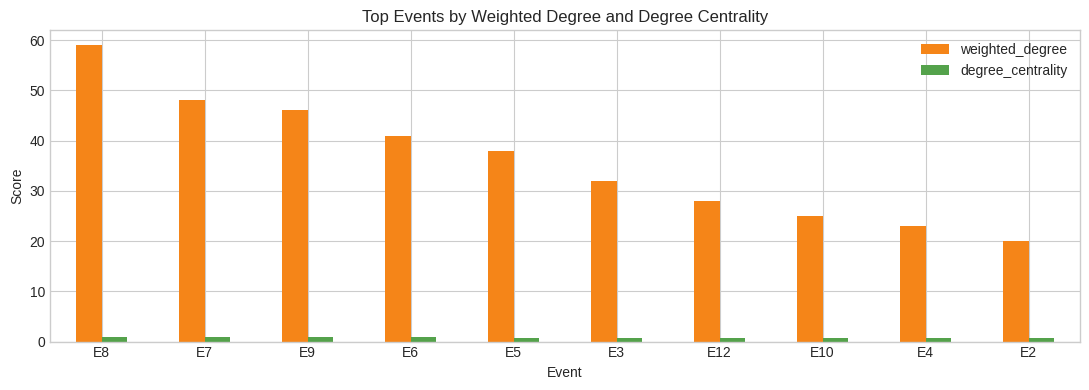

In [10]:
event_metrics[['weighted_degree', 'degree_centrality']].head(10).plot(
    kind='bar', figsize=(11,4), color=['#F58518', '#54A24B']
)
plt.title('Top Events by Weighted Degree and Degree Centrality')
plt.ylabel('Score')
plt.xlabel('Event')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



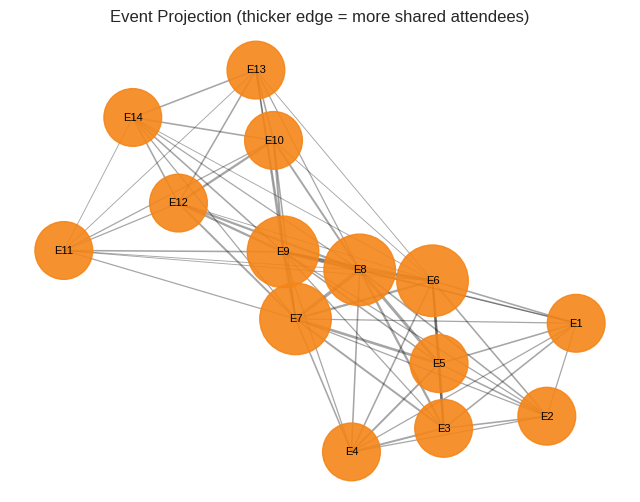

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
pos_e = nx.spring_layout(E, seed=42, weight='weight')
node_sizes_e = [250 + 2400 * event_metrics.loc[n, 'degree_centrality'] for n in E.nodes()]
edge_widths_e = [0.4 + 0.25 * d['weight'] for _, _, d in E.edges(data=True)]

nx.draw_networkx_nodes(E, pos_e, node_size=node_sizes_e, node_color='#F58518', alpha=0.9, ax=ax)
nx.draw_networkx_edges(E, pos_e, width=edge_widths_e, alpha=0.35, ax=ax)
nx.draw_networkx_labels(E, pos_e, font_size=8, ax=ax)

ax.set_title('Event Projection (thicker edge = more shared attendees)')
ax.axis('off')
plt.show()



## 6) Interpretable summary tables


In [12]:
print('Top 5 women by weighted degree')
display(women_metrics.head(5))

print('Top 5 events by weighted degree')
display(event_metrics.head(5))



Top 5 women by weighted degree


,weighted_degree,degree_centrality,betweenness_centrality,clustering
Theresa Anderson,57,1.000000,0.000668,0.351678
Evelyn Jefferson,50,1.000000,0.000668,0.318594
Sylvia Avondale,46,1.000000,0.018464,0.305664
Brenda Rogers,46,0.882353,0.003326,0.359048
Laura Mandeville,45,0.882353,0.003326,0.355817


Top 5 events by weighted degree


,weighted_degree,degree_centrality,betweenness_centrality,clustering
E8,59,1.000000,0.013889,0.292456
E7,48,1.000000,0.028846,0.261580
E9,46,1.000000,0.123932,0.251326
E6,41,1.000000,0.292491,0.233423
E5,38,0.615385,0.000000,0.463081


## 7) Final inference (direct assignment answer)

### Relationships among women
- Women with higher weighted degree and centrality act as social connectors because they co-attend many events with different people.
- Heavier woman-woman edges show stronger relationship overlap (more shared events), indicating tighter social ties.
- The women projection is dense, but central connectors still stand out as bridges between subgroups.

### Relationships among events
- Events with high weighted degree are hub gatherings because they share attendees with many other events.
- Strong event-event edge weights imply event pairs attracted similar women, which suggests related social circles.
- Lower-connectivity events appear more specialized because they share fewer attendees.

